In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1]
x_train = (x_train - 127.5) / 127.5

# Reshape to (28, 28, 1)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')

BUFFER_SIZE = 60000
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)\
    .shuffle(BUFFER_SIZE)\
    .batch(BATCH_SIZE)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

In [4]:
def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                            input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [6]:
generator = build_generator()
discriminator = build_discriminator()

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [8]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2, cmap='gray')
        plt.axis('off')

    plt.show()

In [9]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

gen_losses = []
disc_losses = []

def train(dataset, epochs):
    for epoch in range(epochs):
        g_loss_avg = 0
        d_loss_avg = 0
        batch_count = 0

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)

            g_loss_avg += g_loss
            d_loss_avg += d_loss
            batch_count += 1

        gen_losses.append(g_loss_avg / batch_count)
        disc_losses.append(d_loss_avg / batch_count)

        # Display images every epoch
        generate_and_save_images(generator, epoch + 1, seed)

        print(f'Epoch {epoch+1}, Gen Loss: {g_loss_avg:.4f}, Disc Loss: {d_loss_avg:.4f}')

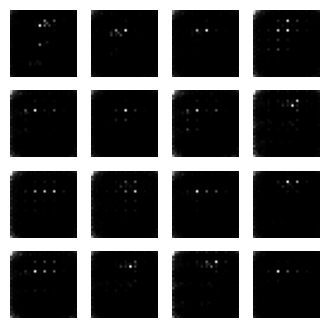

Epoch 1, Gen Loss: 402.0781, Disc Loss: 495.8032


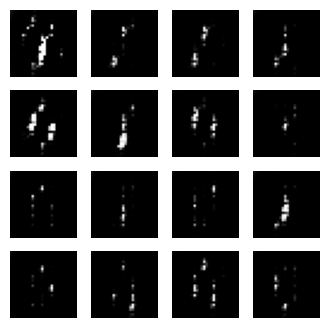

Epoch 2, Gen Loss: 419.8151, Disc Loss: 568.1560


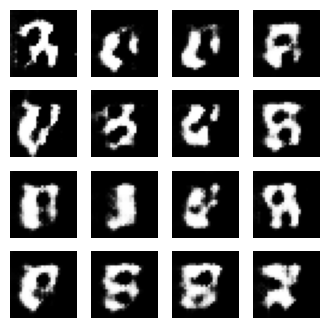

Epoch 3, Gen Loss: 438.8263, Disc Loss: 565.4236


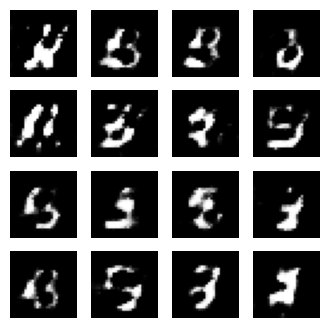

Epoch 4, Gen Loss: 460.2586, Disc Loss: 568.1052


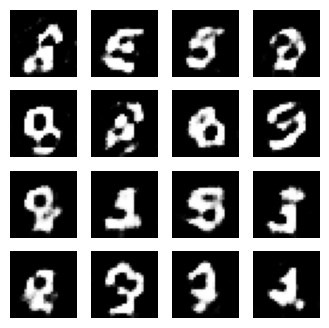

Epoch 5, Gen Loss: 430.5345, Disc Loss: 587.1946


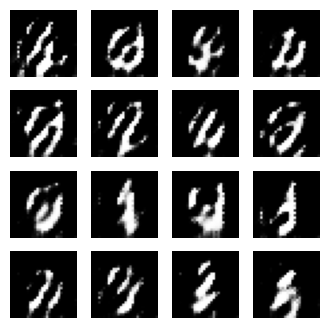

Epoch 6, Gen Loss: 465.5283, Disc Loss: 543.0952


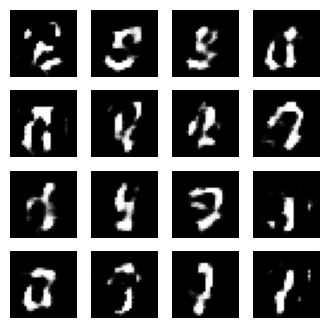

Epoch 7, Gen Loss: 499.5544, Disc Loss: 524.7664


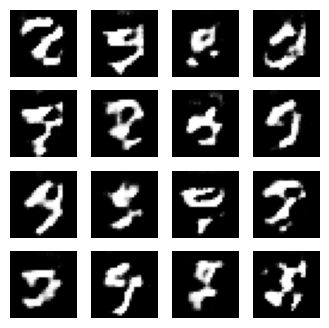

Epoch 8, Gen Loss: 522.2195, Disc Loss: 527.4574


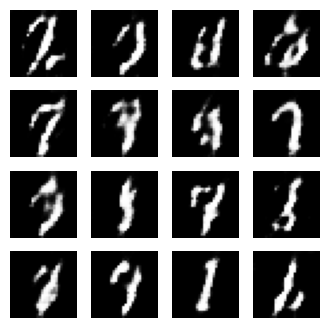

Epoch 9, Gen Loss: 541.1218, Disc Loss: 501.4402


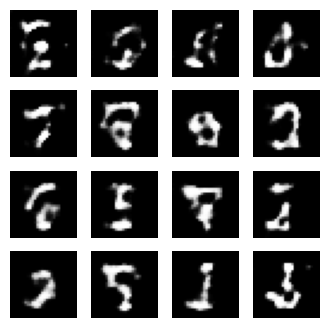

Epoch 10, Gen Loss: 530.6846, Disc Loss: 519.8757


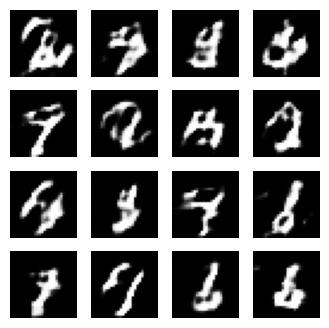

Epoch 11, Gen Loss: 530.8359, Disc Loss: 509.2312


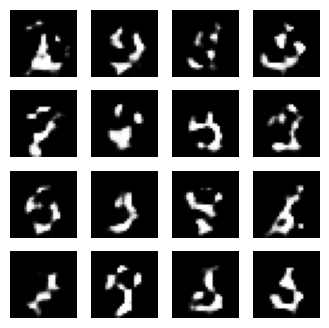

Epoch 12, Gen Loss: 564.8038, Disc Loss: 489.1853


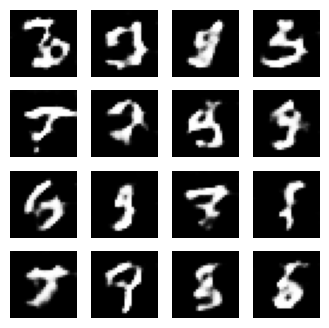

Epoch 13, Gen Loss: 567.1488, Disc Loss: 498.4762


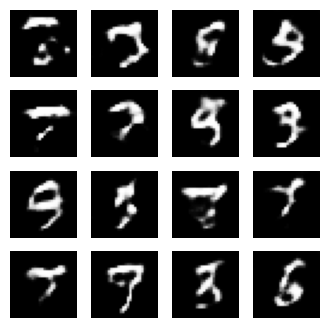

Epoch 14, Gen Loss: 548.2133, Disc Loss: 507.6979


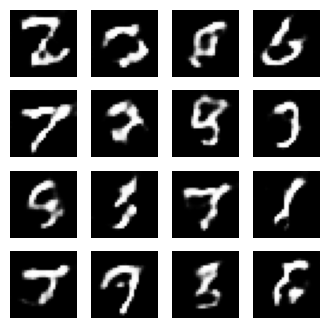

Epoch 15, Gen Loss: 530.1608, Disc Loss: 528.6989


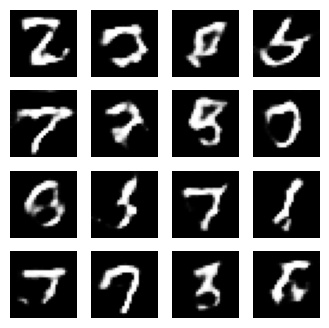

Epoch 16, Gen Loss: 505.3303, Disc Loss: 542.0004


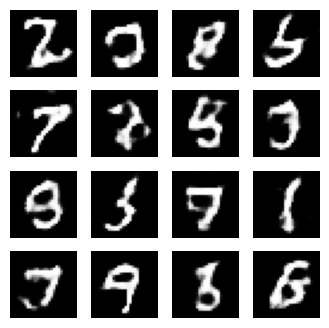

Epoch 17, Gen Loss: 509.3268, Disc Loss: 546.7197


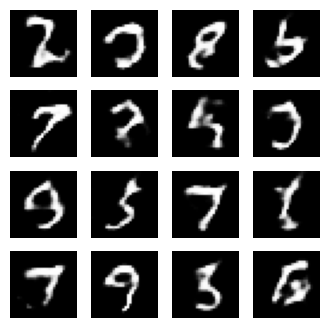

Epoch 18, Gen Loss: 482.3564, Disc Loss: 555.7232


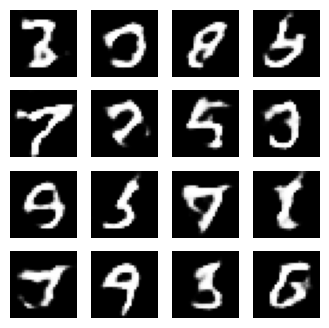

Epoch 19, Gen Loss: 476.8194, Disc Loss: 561.1286


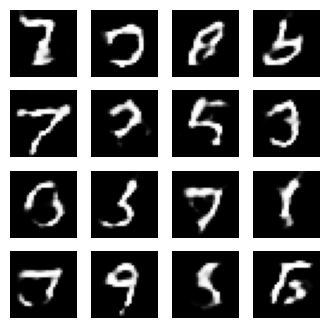

Epoch 20, Gen Loss: 480.0584, Disc Loss: 561.7090


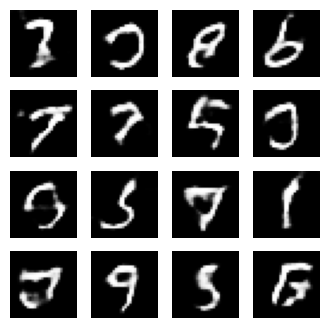

Epoch 21, Gen Loss: 463.4438, Disc Loss: 564.0236


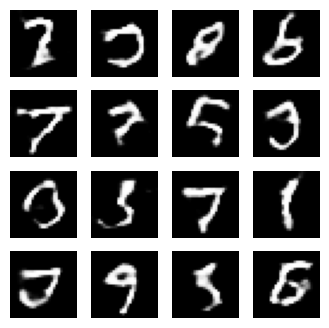

Epoch 22, Gen Loss: 448.4666, Disc Loss: 570.2028


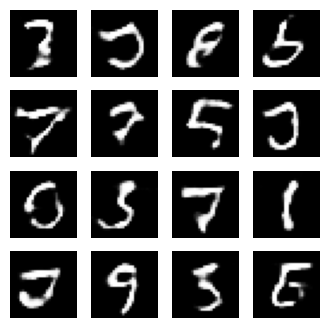

Epoch 23, Gen Loss: 458.7490, Disc Loss: 564.4603


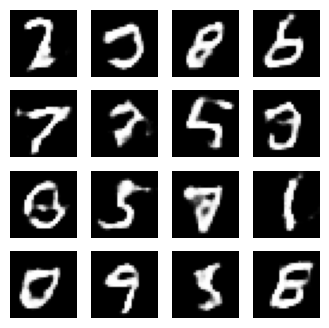

Epoch 24, Gen Loss: 483.1282, Disc Loss: 560.7888


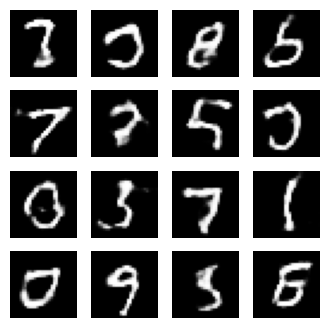

Epoch 25, Gen Loss: 456.4991, Disc Loss: 570.7469


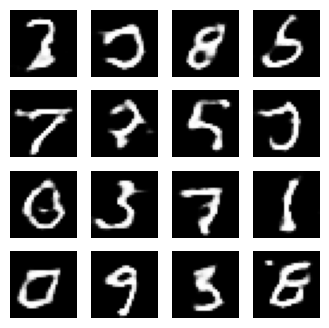

Epoch 26, Gen Loss: 435.3523, Disc Loss: 574.9047


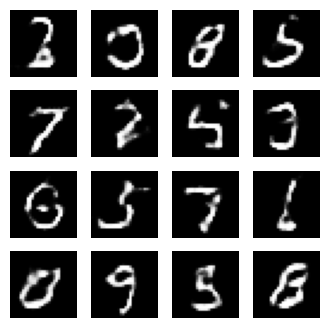

Epoch 27, Gen Loss: 475.0397, Disc Loss: 560.8285


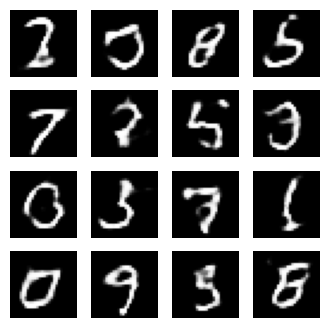

Epoch 28, Gen Loss: 460.8674, Disc Loss: 566.8734


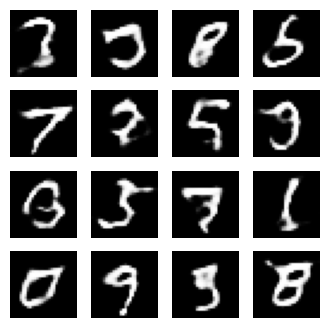

Epoch 29, Gen Loss: 432.2374, Disc Loss: 578.0125


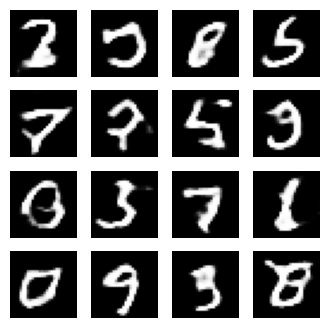

Epoch 30, Gen Loss: 453.6204, Disc Loss: 570.5621


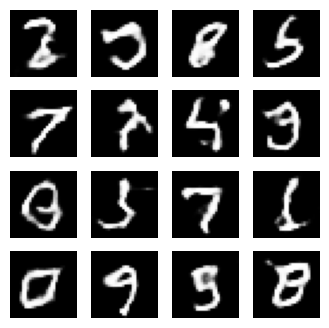

Epoch 31, Gen Loss: 459.0639, Disc Loss: 570.2366


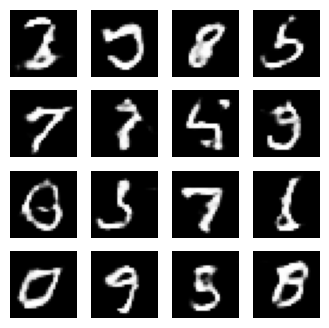

Epoch 32, Gen Loss: 426.7400, Disc Loss: 580.4792


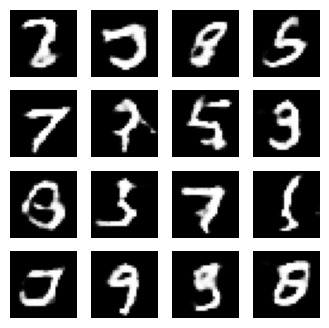

Epoch 33, Gen Loss: 452.8506, Disc Loss: 569.0029


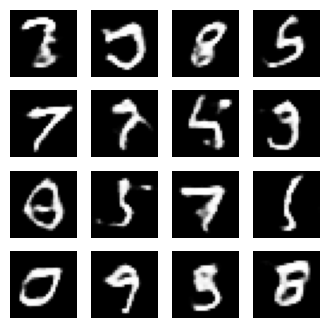

Epoch 34, Gen Loss: 463.2303, Disc Loss: 565.9687


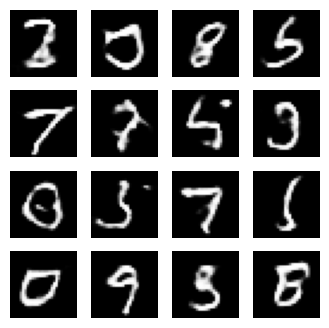

Epoch 35, Gen Loss: 440.4863, Disc Loss: 579.9181


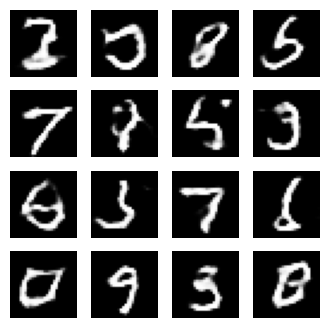

Epoch 36, Gen Loss: 437.2222, Disc Loss: 581.7081


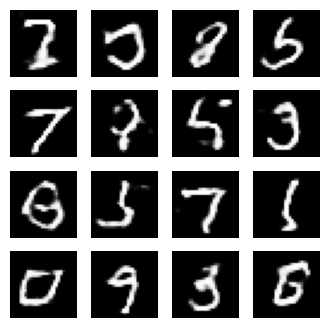

Epoch 37, Gen Loss: 454.6643, Disc Loss: 572.2634


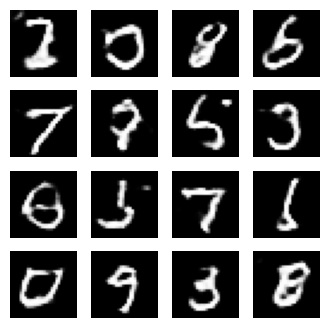

Epoch 38, Gen Loss: 426.9261, Disc Loss: 581.9048


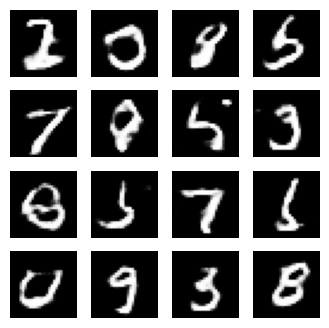

Epoch 39, Gen Loss: 432.1817, Disc Loss: 579.9503


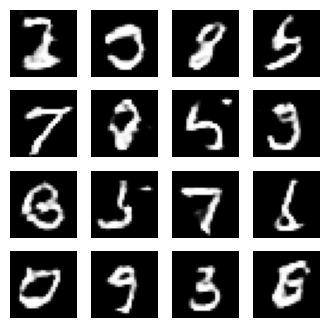

Epoch 40, Gen Loss: 452.9735, Disc Loss: 574.7468


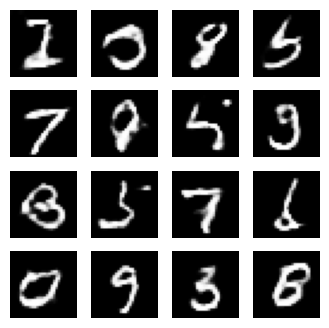

Epoch 41, Gen Loss: 430.5150, Disc Loss: 581.5949


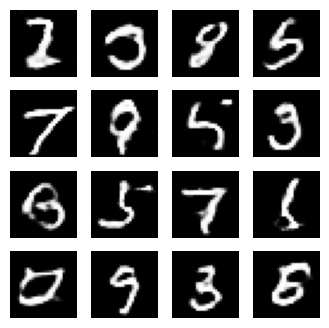

Epoch 42, Gen Loss: 427.7655, Disc Loss: 582.7848


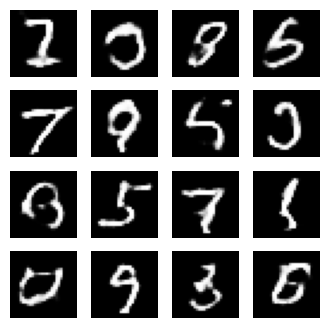

Epoch 43, Gen Loss: 438.7477, Disc Loss: 583.2621


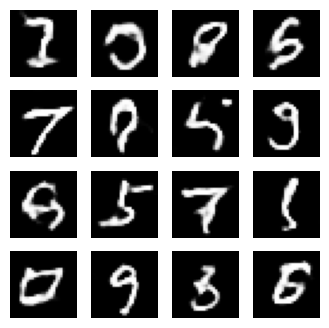

Epoch 44, Gen Loss: 444.5087, Disc Loss: 580.6372


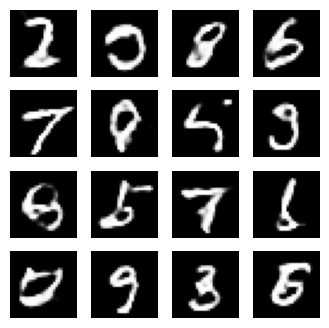

Epoch 45, Gen Loss: 427.2715, Disc Loss: 583.5511


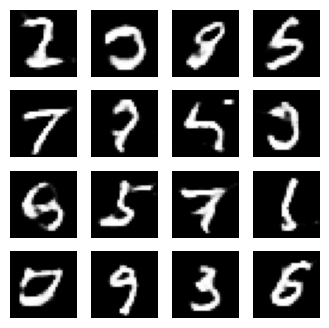

Epoch 46, Gen Loss: 446.3110, Disc Loss: 575.3943


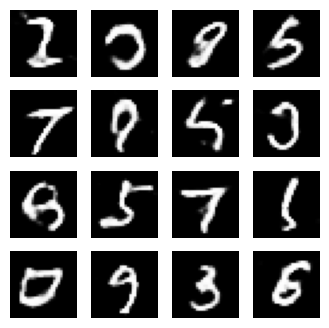

Epoch 47, Gen Loss: 438.8389, Disc Loss: 582.8272


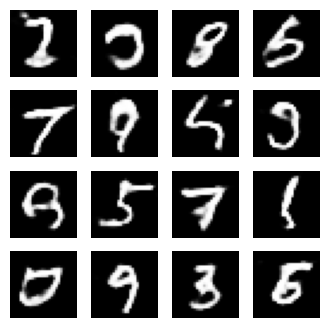

Epoch 48, Gen Loss: 427.2934, Disc Loss: 586.5891


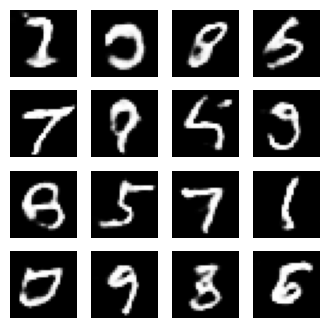

Epoch 49, Gen Loss: 440.2801, Disc Loss: 579.6732


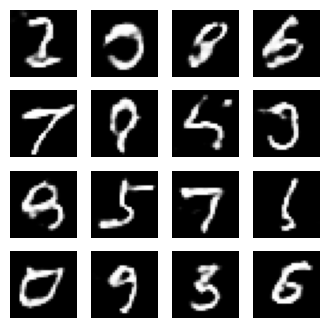

Epoch 50, Gen Loss: 434.1954, Disc Loss: 585.2976


In [10]:
train(train_dataset, EPOCHS)

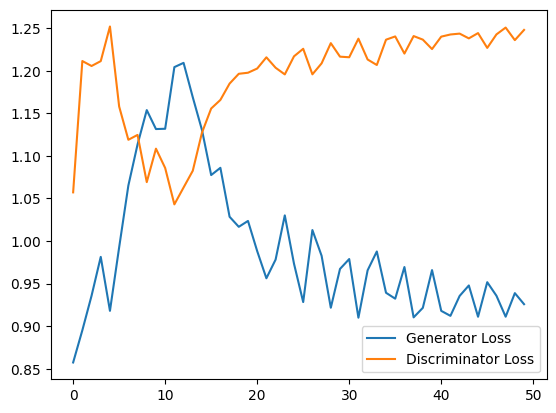

In [11]:
plt.plot(gen_losses, label='Generator Loss')
plt.plot(disc_losses, label='Discriminator Loss')
plt.legend()
plt.show()

The generator loss decreases while discriminator loss increases, indicating that the generator is improving and successfully fooling the discriminator. However, the imbalance suggests that the discriminator is becoming weaker. Ideally, both losses should stabilize around equilibrium.